In [1]:
# !pip install -q datasets transformers evaluate accelerate scikit-learn pandas matplotlib seaborn emoji

In [2]:
import os
import gc
import time
import random
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import evaluate

import torch.nn as nn
import torch.nn.functional as F

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)

/home/experimental/miniconda3/envs/jupyter/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
TASK = "emotion"
SEED = 42

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


# Prepare Dataset (TweetEval - Emotion Task)

In [4]:
dataset = load_dataset("cardiffnlp/tweet_eval", TASK)
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 374
    })
})

In [5]:
label_names = dataset["train"].features["label"].names
num_labels = len(label_names)

print("Number of labels:", num_labels)
print("Labels:", label_names)

print(dataset["train"][0])

Number of labels: 4
Labels: ['anger', 'joy', 'optimism', 'sadness']
{'text': "“Worry is a down payment on a problem you may never have'. \xa0Joyce Meyer.  #motivation #leadership #worry", 'label': 2}


In [6]:
def preprocess_tweet(text):
    new_text = []
    for t in text.split():
        if len(t) > 1:
            t = "@user" if t.startswith("@") and t.count("@") == 1 else t
            t = "http" if t.startswith("http") else t
        new_text.append(t)
    return " ".join(new_text)

def add_preprocessed_text(batch):
    batch["text"] = [preprocess_tweet(t) for t in batch["text"]]
    return batch

dataset = dataset.map(add_preprocessed_text, batched=True)

label
anger       1400
sadness      855
joy          708
optimism     294
Name: count, dtype: int64

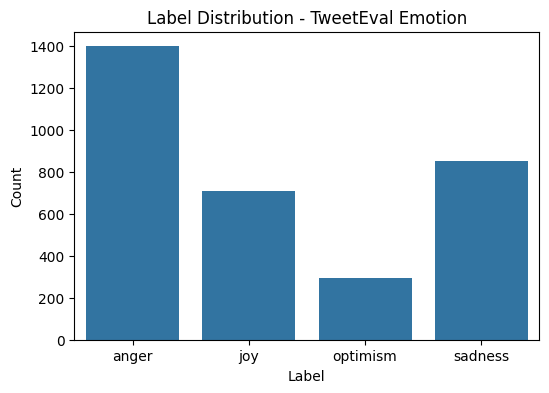

In [7]:
train_labels = dataset["train"]["label"]

df_dist = pd.DataFrame({
    "label_id": train_labels,
    "label": [label_names[i] for i in train_labels]
})

display(df_dist["label"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df_dist, x="label", order=label_names)
plt.title("Label Distribution - TweetEval Emotion")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# CE, SCL and Trainer

In [8]:
class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss.
    features: shape [batch_size, n_views, hidden_dim]
    labels: shape [batch_size]
    """
    def __init__(self, temperature=0.3, base_temperature=0.3):
        super().__init__()
        self.temperature = temperature
        self.base_temperature = base_temperature

    def forward(self, features, labels):
        device = features.device

        if len(features.shape) < 3:
            raise ValueError("features must be [batch_size, n_views, hidden_dim]")

        batch_size = features.shape[0]
        labels = labels.contiguous().view(-1, 1)

        mask = torch.eq(labels, labels.T).float().to(device)

        contrast_count = features.shape[1]
        contrast_feature = torch.cat(torch.unbind(features, dim=1), dim=0)

        anchor_feature = contrast_feature
        anchor_count = contrast_count

        anchor_dot_contrast = torch.div(
            torch.matmul(anchor_feature, contrast_feature.T),
            self.temperature
        )

        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()

        mask = mask.repeat(anchor_count, contrast_count)

        logits_mask = torch.ones_like(mask)
        logits_mask.scatter_(
            1,
            torch.arange(batch_size * anchor_count).view(-1, 1).to(device),
            0
        )

        mask = mask * logits_mask

        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-12)

        mask_pos_pairs = mask.sum(1)
        mask_pos_pairs = torch.where(
            mask_pos_pairs < 1e-6,
            torch.ones_like(mask_pos_pairs),
            mask_pos_pairs
        )

        mean_log_prob_pos = (mask * log_prob).sum(1) / mask_pos_pairs

        loss = - (self.temperature / self.base_temperature) * mean_log_prob_pos
        loss = loss.view(anchor_count, batch_size).mean()

        return loss

In [9]:
class CESCLTrainer(Trainer):
    def __init__(self, *args, scl_weight=0.1, scl_temperature=0.3, **kwargs):
        super().__init__(*args, **kwargs)
        self.scl_weight = scl_weight
        self.scl_loss_fn = SupConLoss(
            temperature=scl_temperature,
            base_temperature=scl_temperature
        )

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        if "labels" not in inputs and "label" in inputs:
            inputs["labels"] = inputs.pop("label")

        labels = inputs["labels"]

        outputs = model(
            **inputs,
            output_hidden_states=True,
            return_dict=True
        )

        ce_loss = outputs.loss

        # Representation của token đầu tiên: CLS-like token
        features = outputs.hidden_states[-1][:, 0, :]
        features = F.normalize(features, p=2, dim=1)
        features = features.unsqueeze(1)

        scl_loss = self.scl_loss_fn(features, labels)

        loss = ce_loss + self.scl_weight * scl_loss

        return (loss, outputs) if return_outputs else loss

# List of Experiments

In [10]:
MODEL_CONFIGS = [
    {
        "short_name": "Rob-rt",
        "hf_name": "roberta-base",
        "lr": 1e-5,
        "batch_size": 16,
        "epochs": 5,
        "max_length": 128,
    },
    {
        "short_name": "Rob-tw",
        "hf_name": "cardiffnlp/twitter-roberta-base",
        "lr": 1e-5,
        "batch_size": 16,
        "epochs": 5,
        "max_length": 128,
    },
    {
        "short_name": "XLM-r",
        "hf_name": "xlm-roberta-base",
        "lr": 1e-5,
        "batch_size": 16,
        "epochs": 5,
        "max_length": 128,
    },
    {
        "short_name": "XLM-tw",
        "hf_name": "cardiffnlp/twitter-xlm-roberta-base",
        "lr": 1e-5,
        "batch_size": 16,
        "epochs": 5,
        "max_length": 128,
    },
    {
        "short_name": "BERTweet",
        "hf_name": "vinai/bertweet-base",
        "lr": 1e-5,
        "batch_size": 16,
        "epochs": 5,
        "max_length": 128,
    },
    {
        "short_name": "TimeLM-19",
        "hf_name": "cardiffnlp/twitter-roberta-base-2019-90m",
        "lr": 1e-5,
        "batch_size": 16,
        "epochs": 5,
        "max_length": 128,
    },
    {
        "short_name": "TimeLM-21",
        "hf_name": "cardiffnlp/twitter-roberta-base-2021-124m",
        "lr": 1e-5,
        "batch_size": 16,
        "epochs": 5,
        "max_length": 128,
    },
]

ROB_BS_CONFIGS = [
    {
        "short_name": "Rob-bs-CE",
        "hf_name": "roberta-base",
        "training_mode": "ce",
        "lr": 1e-5,
        "batch_size": 16,
        "epochs": 5,
        "max_length": 128,
    },
    # {
    #     "short_name": "Rob-bs-CE-SCL",
    #     "hf_name": "roberta-base",
    #     "training_mode": "ce_scl",
    #     "scl_weight": 0.1,
    #     "scl_temperature": 0.3,
    #     "lr": 1e-5,
    #     "batch_size": 16,
    #     "epochs": 5,
    #     "max_length": 128,
    # },
]

In [11]:
def get_tokenizer(model_name):
    if model_name == "vinai/bertweet-base":
        return AutoTokenizer.from_pretrained(model_name, use_fast=False, normalization=True)
    else:
        return AutoTokenizer.from_pretrained(model_name, use_fast=True)

def tokenize_dataset(dataset, tokenizer, max_length):
    def tokenize_function(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=max_length
        )

    tokenized = dataset.map(tokenize_function, batched=True)

    return tokenized

# Metrics

In [12]:
def extract_logits(predictions):
    """
    Trainer có thể trả predictions là:
    - numpy array logits
    - tuple/list: (logits, hidden_states, ...)
    Ta chỉ lấy logits để tính metric.
    """
    if isinstance(predictions, (tuple, list)):
        return predictions[0]
    return predictions


def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    logits = extract_logits(predictions)
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    weighted_f1 = f1_score(labels, preds, average="weighted")
    macro_precision = precision_score(labels, preds, average="macro", zero_division=0)
    macro_recall = recall_score(labels, preds, average="macro", zero_division=0)

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
    }

# Training Pipeline

In [13]:
def train_one_model(config, dataset, label_names, seed=42):
    short_name = config["short_name"]
    model_name = config["hf_name"]
    lr = config["lr"]
    batch_size = config["batch_size"]
    epochs = config["epochs"]
    max_length = config["max_length"]

    training_mode = config.get("training_mode", "ce")
    scl_weight = config.get("scl_weight", 0.1)
    scl_temperature = config.get("scl_temperature", 0.3)

    print("=" * 100)
    print(f"Training model: {short_name}")
    print(f"HF model: {model_name}")
    print("=" * 100)

    set_seed(seed)

    tokenizer = get_tokenizer(model_name)
    tokenized_dataset = tokenize_dataset(dataset, tokenizer, max_length=max_length)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(label_names),
        id2label={i: label for i, label in enumerate(label_names)},
        label2id={label: i for i, label in enumerate(label_names)},
        ignore_mismatched_sizes=True
    )

    output_dir = f"./outputs/{TASK}/{short_name}"

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,
        num_train_epochs=epochs,
        weight_decay=0.01,
        logging_steps=50,
        load_best_model_at_end=False,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=seed,
    )

    if training_mode == "ce_scl":
        trainer_class = CESCLTrainer
        trainer_extra_kwargs = {
            "scl_weight": scl_weight,
            "scl_temperature": scl_temperature,
        }
    else:
        trainer_class = Trainer
        trainer_extra_kwargs = {}
    
    trainer = trainer_class(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        **trainer_extra_kwargs
    )

    start_time = time.time()
    trainer.train()
    train_time = time.time() - start_time

    val_results = trainer.evaluate(tokenized_dataset["validation"])
    test_results = trainer.evaluate(tokenized_dataset["test"])

    pred_output = trainer.predict(tokenized_dataset["test"])

    y_true = pred_output.label_ids
    test_logits = extract_logits(pred_output.predictions)
    y_pred = np.argmax(test_logits, axis=-1)

    report = classification_report(
        y_true,
        y_pred,
        target_names=label_names,
        output_dict=True,
        zero_division=0
    )

    result = {
        "model": short_name,
        "hf_model": model_name,
        "task": TASK,
        "accuracy": test_results["eval_accuracy"],
        "macro_f1": test_results["eval_macro_f1"],
        "weighted_f1": test_results["eval_weighted_f1"],
        "macro_precision": test_results["eval_macro_precision"],
        "macro_recall": test_results["eval_macro_recall"],
        "eval_loss": test_results["eval_loss"],
        "train_time_sec": train_time,
        "epochs": epochs,
        "lr": lr,
        "batch_size": batch_size,
        "max_length": max_length,
        "training_mode": training_mode,
        "scl_weight": scl_weight if training_mode == "ce_scl" else None,
        "scl_temperature": scl_temperature if training_mode == "ce_scl" else None,
    }

    os.makedirs("./results", exist_ok=True)
    os.makedirs("./saved_models", exist_ok=True)

    pd.DataFrame([result]).to_csv(f"./results/{TASK}_{short_name}_metrics.csv", index=False)

    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(f"./results/{TASK}_{short_name}_classification_report.csv")

    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=label_names, columns=label_names)
    cm_df.to_csv(f"./results/{TASK}_{short_name}_confusion_matrix.csv")

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {short_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(f"./results/{TASK}_{short_name}_confusion_matrix.png", dpi=200)
    plt.show()

    save_path = f"./saved_models/{TASK}_{short_name}"
    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)

    del trainer
    del model
    del tokenizer
    del tokenized_dataset
    torch.cuda.empty_cache()
    gc.collect()

    return result

# Training

In [14]:
# rob_bs_results = []

# for config in ROB_BS_CONFIGS:
#     result = train_one_model(config, dataset, label_names)
#     rob_bs_results.append(result)

# df_rob_bs = pd.DataFrame(rob_bs_results)
# df_rob_bs["macro_f1_percent"] = df_rob_bs["macro_f1"] * 100

# df_rob_bs

In [15]:
# # Rob-bs: pure roberta-base baseline (no fine-tuning)
# SHORT_NAME = "Rob-bs"
# HF_NAME = "roberta-base"
# MAX_LENGTH = 128

# set_seed(SEED)

# tokenizer_bs = get_tokenizer(HF_NAME)
# tokenized_dataset_bs = tokenize_dataset(dataset, tokenizer_bs, max_length=MAX_LENGTH)
# data_collator_bs = DataCollatorWithPadding(tokenizer=tokenizer_bs)

# model_bs = AutoModelForSequenceClassification.from_pretrained(
#     HF_NAME,
#     num_labels=num_labels,
#     id2label={i: label for i, label in enumerate(label_names)},
#     label2id={label: i for i, label in enumerate(label_names)},
#     ignore_mismatched_sizes=True
# )

# training_args_bs = TrainingArguments(
#     output_dir=f"./outputs/{TASK}/{SHORT_NAME}",
#     per_device_eval_batch_size=32,
#     fp16=torch.cuda.is_available(),
#     report_to="none",
# )

# trainer_bs = Trainer(
#     model=model_bs,
#     args=training_args_bs,
#     data_collator=data_collator_bs,
#     compute_metrics=compute_metrics,
# )

# pred_output_bs = trainer_bs.predict(tokenized_dataset_bs["test"])

# y_true_bs = pred_output_bs.label_ids
# test_logits_bs = extract_logits(pred_output_bs.predictions)
# y_pred_bs = np.argmax(test_logits_bs, axis=-1)

# report_bs = classification_report(
#     y_true_bs, y_pred_bs,
#     target_names=label_names,
#     output_dict=True,
#     zero_division=0
# )

# test_results_bs = trainer_bs.evaluate(tokenized_dataset_bs["test"])

# result_bs = {
#     "model": SHORT_NAME,
#     "hf_model": HF_NAME,
#     "task": TASK,
#     "accuracy": test_results_bs["eval_accuracy"],
#     "macro_f1": test_results_bs["eval_macro_f1"],
#     "weighted_f1": test_results_bs["eval_weighted_f1"],
#     "macro_precision": test_results_bs["eval_macro_precision"],
#     "macro_recall": test_results_bs["eval_macro_recall"],
#     "eval_loss": test_results_bs["eval_loss"],
#     "training_mode": "none",
# }

# os.makedirs("./results", exist_ok=True)
# os.makedirs("./saved_models", exist_ok=True)

# pd.DataFrame([result_bs]).to_csv(f"./results/{TASK}_{SHORT_NAME}_metrics.csv", index=False)

# report_df_bs = pd.DataFrame(report_bs).transpose()
# report_df_bs.to_csv(f"./results/{TASK}_{SHORT_NAME}_classification_report.csv")

# cm_bs = confusion_matrix(y_true_bs, y_pred_bs)
# cm_df_bs = pd.DataFrame(cm_bs, index=label_names, columns=label_names)
# cm_df_bs.to_csv(f"./results/{TASK}_{SHORT_NAME}_confusion_matrix.csv")

# plt.figure(figsize=(6, 5))
# sns.heatmap(cm_df_bs, annot=True, fmt="d", cmap="Blues")
# plt.title(f"Confusion Matrix - {SHORT_NAME} (no fine-tuning)")
# plt.xlabel("Predicted")
# plt.ylabel("True")
# plt.tight_layout()
# plt.savefig(f"./results/{TASK}_{SHORT_NAME}_confusion_matrix.png", dpi=200)
# plt.show()

# save_path_bs = f"./saved_models/{TASK}_{SHORT_NAME}"
# trainer_bs.save_model(save_path_bs)
# tokenizer_bs.save_pretrained(save_path_bs)

# display(pd.DataFrame([result_bs]))

# del trainer_bs, model_bs, tokenizer_bs, tokenized_dataset_bs
# torch.cuda.empty_cache()
# gc.collect()


In [16]:
# Find confusing examples: cases where 4 models disagree
CONFUSION_MODELS = [
    {"short_name": "rob_rt",      "path": "./saved_models/emotion_Rob-rt"},
    {"short_name": "rob_tw",      "path": "./saved_models/emotion_Rob-tw"},
    {"short_name": "rob_ce",      "path": "./saved_models/emotion_Rob-bs-CE"},
    {"short_name": "rob_ce_cls",  "path": "./saved_models/emotion_Rob-bs-CE-SCL"},
]

all_preds = {}

for cfg in CONFUSION_MODELS:
    name = cfg["short_name"]
    path = cfg["path"]
    print(f"Running inference: {name}")

    tok = AutoTokenizer.from_pretrained(path, use_fast=True)
    tokenized_ds = tokenize_dataset(dataset, tok, max_length=128)
    collator = DataCollatorWithPadding(tokenizer=tok)

    mdl = AutoModelForSequenceClassification.from_pretrained(path)

    args = TrainingArguments(
        output_dir=f"./outputs/confusion/{name}",
        per_device_eval_batch_size=32,
        fp16=torch.cuda.is_available(),
        report_to="none",
    )

    trainer = Trainer(
        model=mdl,
        args=args,
        data_collator=collator,
    )

    pred_out = trainer.predict(tokenized_ds["test"])
    logits = extract_logits(pred_out.predictions)
    pred_ids = np.argmax(logits, axis=-1)
    all_preds[name] = [label_names[i] for i in pred_ids]

    del trainer, mdl, tok, tokenized_ds
    torch.cuda.empty_cache()
    gc.collect()

# Build DataFrame
df_conf = pd.DataFrame({
    "text":       dataset["test"]["text"],
    "true_label": [label_names[i] for i in dataset["test"]["label"]],
    **all_preds,
})

pred_cols = ["rob_rt", "rob_tw", "rob_ce", "rob_ce_cls"]
df_conf["n_unique"] = df_conf[pred_cols].nunique(axis=1)

# Filter: at least 3 different predictions (maximally confusing first)
df_disagree = df_conf[df_conf["n_unique"] >= 3].sort_values("n_unique", ascending=False)

print(f"Total test examples   : {len(df_conf)}")
print(f"n_unique==2 (partial) : {(df_conf['n_unique']==2).sum()}")
print(f"n_unique==3           : {(df_conf['n_unique']==3).sum()}")
print(f"n_unique==4 (all diff): {(df_conf['n_unique']==4).sum()}")
print()

display(df_disagree[["text", "true_label"] + pred_cols + ["n_unique"]].head(10).reset_index(drop=True))

df_disagree.to_csv("./results/emotion_confusing_examples.csv", index=False)
print("Saved: ./results/emotion_confusing_examples.csv")


Running inference: rob_rt


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4750.25it/s]
[RANK 0] Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Running inference: rob_tw


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4582.22it/s]
[RANK 0] Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Running inference: rob_ce


...

Running inference: rob_ce_cls


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5330.12it/s]
[RANK 0] Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Total test examples   : 1421
n_unique==2 (partial) : 179
n_unique==3           : 1
n_unique==4 (all diff): 0



,text,true_label,rob_rt,rob_tw,rob_ce,rob_ce_cls,n_unique
0,And my mind and my soul. Who made him substitu...,joy,optimism,sadness,optimism,joy,3


Saved: ./results/emotion_confusing_examples.csv


In [17]:
# all_results = []

# for config in MODEL_CONFIGS:
#     result = train_one_model(config, dataset, label_names)
#     all_results.append(result)

# df_results = pd.DataFrame(all_results)
# df_results = df_results.sort_values("macro_f1", ascending=False)

# display(df_results)

# df_results.to_csv(f"./results/{TASK}_all_model_results.csv", index=False)

# Results

In [18]:
# df_results = pd.DataFrame(all_results)
# df_results = df_results.sort_values("macro_f1", ascending=False)

# display(df_results)

# df_results.to_csv(f"./results/{TASK}_all_model_results.csv", index=False)

In [19]:
# paper_emotion_scores = {
#     "Rob-rt": 78.5,
#     "Rob-tw": 72.0,
#     "XLM-r": 72.3,
#     "XLM-tw": 77.0,
#     "BERTweet": 79.3,
#     "TimeLM-19": 81.0,
#     "TimeLM-21": 80.2,
#     "Rob-bs (CE)": 76.1,
#     "Rob-bs (CE+SCL)": 78.1,
# }

# df_compare = df_results.copy()
# df_compare["our_macro_f1_percent"] = df_compare["macro_f1"] * 100
# df_compare["paper_emotion_macro_f1"] = df_compare["model"].map(paper_emotion_scores)
# df_compare["gap"] = df_compare["our_macro_f1_percent"] - df_compare["paper_emotion_macro_f1"]

# df_compare[[
#     "model",
#     "hf_model",
#     "our_macro_f1_percent",
#     "paper_emotion_macro_f1",
#     "gap",
#     "accuracy",
#     "train_time_sec"
# ]]